In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [2]:
marker_idx = 42
mani_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 32, 43, 54, 65, 76, 87, 98, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
corner_idx = [10, 120]

mani_dx_dy = np.loadtxt('mani_dx_dy.csv', delimiter=',')

mani_j = mani_dx_dy[marker_idx*2:marker_idx*2+2, :]

area_list = []
for idx in range(len(mani_list)):
    j = mani_j[:, idx*2:idx*2+2]
    u, s, v = np.linalg.svd(j)
    if mani_list[idx] in corner_idx:
        area_tmp = s[0] * s[1] * np.pi * 1 * 3/ 4
    else:
        area_tmp = s[0] * s[1] * np.pi / 2
    area_list.append(area_tmp)
    # print(mani_list[idx], area_tmp, s)

In [83]:
"""
使用数值法计算可操作性
"""
def angle_from_a_to_b(a, b):
    # 计算从向量a逆时针到向量b的角度(弧度)
    dot_prod = np.dot(a, b)
    cross_prod = np.cross(a, b)
    angle = np.arctan2(cross_prod, dot_prod)
    return angle


def rotate_vector(v, theta):
    # 旋转向量v by theta弧度
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, v)


def generate_unit_vectors(u, v, n):
    ang = angle_from_a_to_b(u, v)
    step = ang / (n - 1)
    vectors = np.array([rotate_vector(u, i * step) for i in range(n)])
    return vectors


vec_N = 100
points_sum_list = []
direction_start_sum = np.vstack((np.repeat([np.array([1, 0])], 9, axis=0), np.repeat([np.array([0, -1])], 10, axis=0), np.repeat([np.array([-1, 0])], 10, axis=0)))
direction_end_sum = np.vstack((np.repeat([np.array([-1, 0])], 10, axis=0), np.repeat([np.array([0, 1])], 10, axis=0), np.repeat([np.array([0, 1])], 9, axis=0)))

n = len(mani_list)
# 获取上三角矩阵的索引，从而避免重复的组合, k=1表示对角线上方的第一个元素开始，确保不会选择相同的元素
rows, cols = np.triu_indices(n, k=1)

# 使用这些索引来获取所有可能的组合
combinations = np.array([(mani_list[i], mani_list[j]) for i, j in zip(rows, cols)])

for combin in combinations:
    # print(combin)
    idx1_value, idx2_value = combin
    idx1, idx2 = mani_list.index(idx1_value), mani_list.index(idx2_value)
    j1 = mani_j[:, idx1*2:idx1*2+2]
    j2 = mani_j[:, idx2*2:idx2*2+2]
    
    direction_start_1, direction_start_2 = direction_start_sum[idx1], direction_start_sum[idx2]         # 起始方向
    direction_end_1, direction_end_2 = direction_end_sum[idx1], direction_end_sum[idx2]                 # 终止方向
    
    vectors1 = generate_unit_vectors(direction_start_1, direction_end_1, vec_N)
    vectors2 = generate_unit_vectors(direction_start_2, direction_end_2, vec_N)
    
    vectors1_j = (j1 @ vectors1.T).T
    vectors2_j = (j2 @ vectors2.T).T
    # vectors1_j = vectors1
    # vectors2_j = vectors2

    num_1, dim = vectors1_j.shape
    num_2, dim = vectors2_j.shape

    vectors1_reshape = vectors1_j[:, np.newaxis, :]
    vectors2_reshape = vectors1_j[np.newaxis, :, :]

    vector_sums = vectors1_reshape + vectors2_reshape

    vector_sums_reshape = vector_sums.reshape(-1, dim)

    points_sum_list.append(vector_sums_reshape)

9 119
19.755301182854044 199.75530118285403


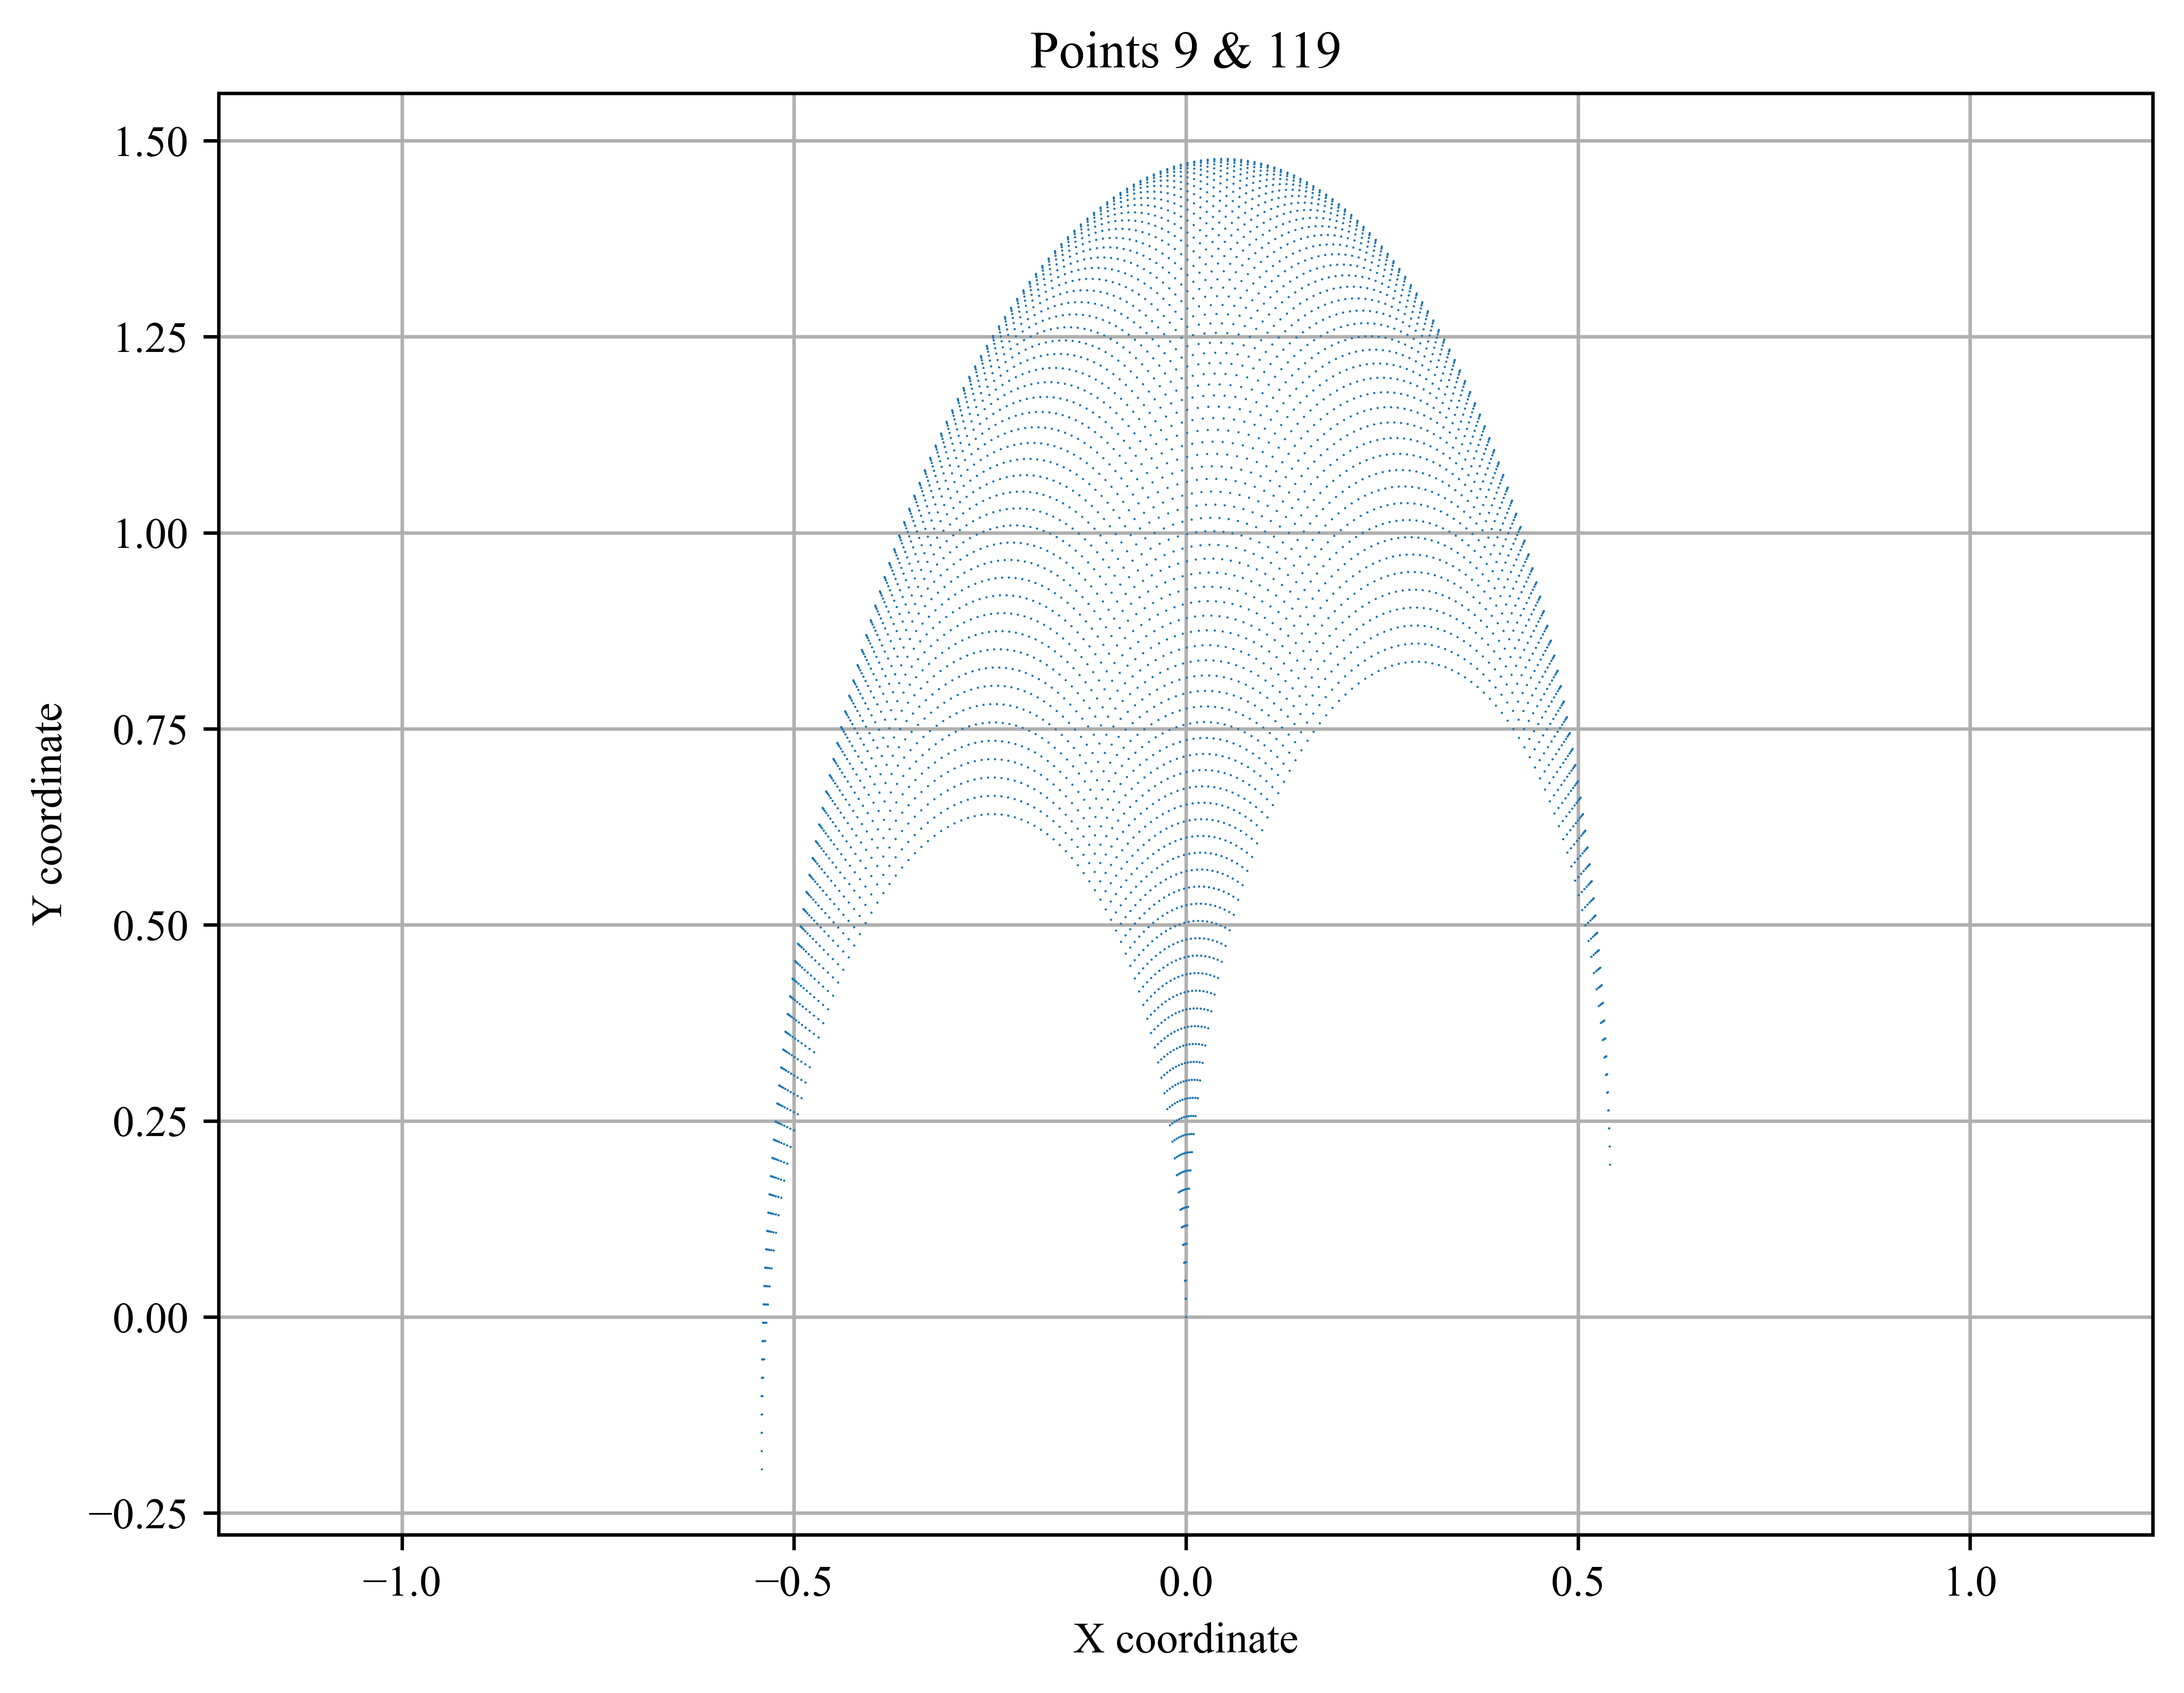

Total area: 1.0484727771524873


In [92]:
"""
画出外轮廓并且计算面积
"""

def interval_angles(thetas):
    # 将角度转换为连续的区间
    theat_min, theta_max = min(thetas), max(thetas)
    if theta_min - 0 < 0.02:
        if 2 * np.pi - theta_max < 0.02:
            thetas = thetas - np.pi
    return thetas
        

idx = 214
points = points_sum_list[idx]
print(combinations[idx][0], combinations[idx][1])

# 转换为极坐标
r = np.sqrt(points[:,0]**2 + points[:, 1]**2)
theta = np.arctan2(points[:, 1], points[:, 0]) % (2 * np.pi)  # 使用atan2计算角度，并将负角度转换为正角度

theta = interval_angles(theta)

# 按角度排序
sorted_indices = np.argsort(theta)
r_sorted = r[sorted_indices]
theta_sorted = theta[sorted_indices]

ang_N = 220
theta_min, theta_max = theta_sorted[0], theta_sorted[-1]
print(np.rad2deg(theta_min), np.rad2deg(theta_max))
angle_interval = (theta_max-theta_min) / ang_N  # 每段的角度
angles = np.linspace(theta_min, theta_max, ang_N+1)  # N+1是因为我们需要N个区间的边界点

# 选取每个区间中极径最大的点，记录最大极径，作为该区间的外轮廓同时计算这个区间的面积
max_r_per_interval = np.empty(ang_N)
contour_points = np.empty((ang_N, 2))  # 存储轮廓点
area_per_interval = np.empty(ang_N)

# 循环每个区间寻找最大极径的点
for i in range(ang_N):
    if i < ang_N - 1:
        interval_indices = (theta_sorted >= angles[i]) & (theta_sorted < angles[i+1])
    else:
        interval_indices = (theta_sorted >= angles[i]) & (theta_sorted <= angles[i+1])
    r_interval = r_sorted[interval_indices]
    theta_interval = theta_sorted[interval_indices]
    
    # 如果区间内有点，则记录最大半径的点，否则记录为None
    if len(r_interval) > 0:
        max_r = np.max(r_interval)
        max_theta = theta_interval[np.argmax(r_interval)]
    else:
        max_r = None
        max_theta = (angles[i] + angles[i+1]) / 2  # 没有点时，取区间的中点角度
    
    max_r_per_interval[i] = max_r
    contour_points[i] = [max_theta, max_r] if max_r is not None else [max_theta, 0]
    
    # 计算区间面积，如果max_r为None，则面积为0
    area_per_interval[i] = 0.5 * max_r**2 * angle_interval if max_r is not None else 0

# 画出所有区间的外轮廓，并输出区间面积的和将极坐标点转换回笛卡尔坐标系用于绘图
x_contour = contour_points[:, 1] * np.cos(contour_points[:, 0])
y_contour = contour_points[:, 1] * np.sin(contour_points[:, 0])

start_point = np.array([r_sorted[0]*np.cos(theta_sorted[0]), r_sorted[0]*np.sin(theta_sorted[0])])
end_point = np.array([r_sorted[-1]*np.cos(theta_sorted[-1]), r_sorted[-1]*np.sin(theta_sorted[-1])])

x_contour = np.concatenate([[start_point[0]], x_contour, [end_point[0]]])
y_contour = np.concatenate([[start_point[1]], y_contour, [end_point[1]]])

# 绘制轮廓
fig, ax = plt.subplots(figsize=(8, 6), dpi=1000)
ax.scatter(points[:, 0], points[:, 1], s=1, marker='.', edgecolors='None', zorder=3)
# ax.scatter(x_contour, y_contour)
# ax.plot(x_contour, y_contour, 'r-')
# ax.plot([0., start_point[0]], [0., start_point[1]], 'r-')  # 闭合轮廓
# ax.plot([0., end_point[0]], [0., end_point[1]], 'r-')  # 闭合轮廓
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Points {combinations[idx][0]} & {combinations[idx][1]}')
ax.axis('equal')
ax.grid(True, zorder=1)

plt.show()

# 输出面积和
total_area = np.nansum(area_per_interval)  # 使用nansum来忽略None值
print(f'Total area: {total_area}')

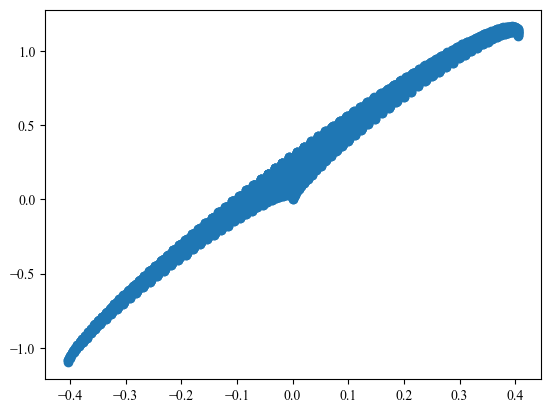

In [8]:
j1 = mani_j[:, 0:2]
j2 = mani_j[:, 2:4]

vectors1 = generate_unit_vectors(np.array([1, 0]), np.array([-1, 0]), 50)
vectors2 = generate_unit_vectors(np.array([1, 0]), np.array([-1, 0]), 50)

vectors1_j = (j1 @ vectors1.T).T
vectors2_j = (j2 @ vectors2.T).T

num_1, dim = vectors1_j.shape
num_2, dim = vectors2_j.shape

vectors1_reshape = vectors1_j[:, np.newaxis, :]
vectors2_reshape = vectors1_j[np.newaxis, :, :]

vector_sums = vectors1_reshape + vectors2_reshape

vector_sums_reshape = vector_sums.reshape(-1, dim)

plt.scatter(vector_sums_reshape[:, 0], vector_sums_reshape[:, 1])
plt.show()